<a href="https://colab.research.google.com/github/manaswi92/SCT_DS_4/blob/main/task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import zipfile

file_path = 'US_Accidents_March23.csv'
zip_file_path = 'archive.zip'

# Check if the zip file exists and extract it
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"'{zip_file_path}' extracted successfully.")

if os.path.exists(file_path):
    cols_to_use = ['Severity', 'Start_Time', 'City', 'State', 'Weather_Condition',
                   'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
                   'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
                   'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset']

    df_accidents = pd.read_csv(file_path, usecols=cols_to_use)

    df_accidents['Start_Time'] = pd.to_datetime(df_accidents['Start_Time'], errors='coerce')
    df_accidents['Hour'] = df_accidents['Start_Time'].dt.hour

    print("Dataset loaded successfully.")
    display(df_accidents.head())
else:
    df_accidents = None
    print(f"Warning: {file_path} not found. Please upload it to the /content/ folder to run the analysis or ensure 'archive.zip' contains it.")

'archive.zip' extracted successfully.
Dataset loaded successfully.


,Severity,Start_Time,City,State,Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Hour
0,3,2016-02-08 05:46:00,Dayton,OH,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,5.0
1,2,2016-02-08 06:07:59,Reynoldsburg,OH,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,6.0
2,2,2016-02-08 06:49:27,Williamsburg,OH,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,6.0
3,3,2016-02-08 07:23:34,Dayton,OH,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,7.0
4,2,2016-02-08 07:39:07,Dayton,OH,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,7.0


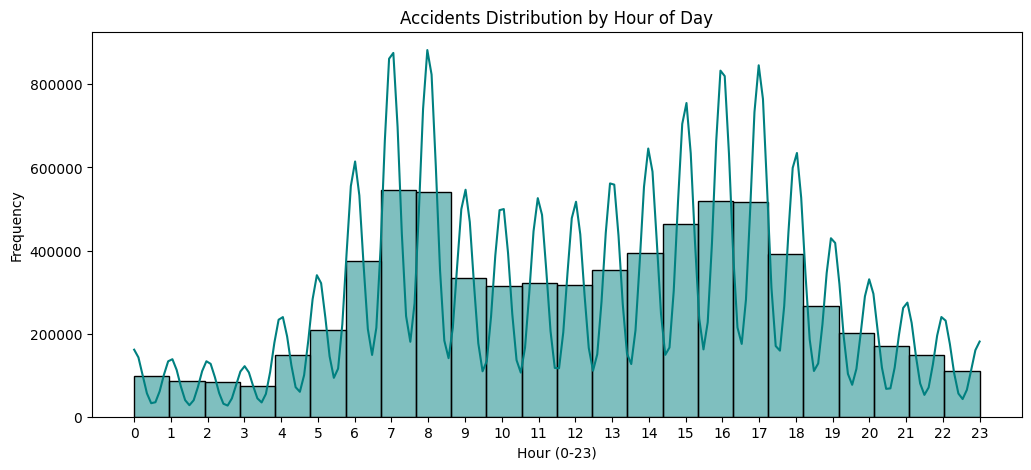

In [8]:
if 'df_accidents' in locals() and df_accidents is not None:
    plt.figure(figsize=(12, 5))
    sns.histplot(df_accidents['Hour'].dropna(), bins=24, kde=True, color='teal')
    plt.title('Accidents Distribution by Hour of Day')
    plt.xlabel('Hour (0-23)')
    plt.ylabel('Frequency')
    plt.xticks(range(0, 24))
    plt.show()
else:
    print("Data not loaded. Skipping visualization.")

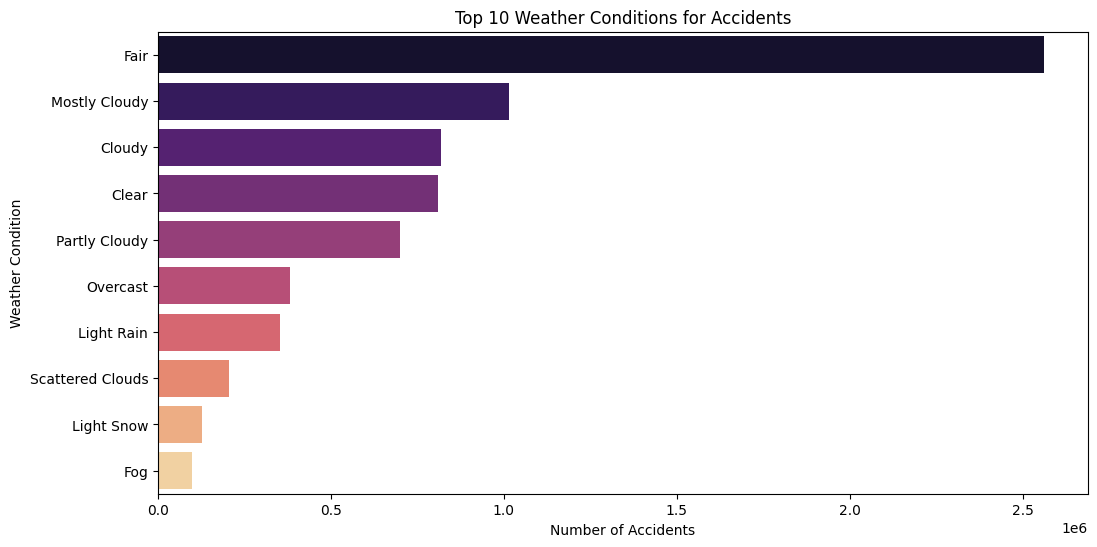

In [10]:
if 'df_accidents' in locals() and df_accidents is not None:
    plt.figure(figsize=(12, 6))
    weather_counts = df_accidents['Weather_Condition'].value_counts().head(10)
    sns.barplot(x=weather_counts.values, y=weather_counts.index, palette='magma', hue=weather_counts.index, legend=False)
    plt.title('Top 10 Weather Conditions for Accidents')
    plt.xlabel('Number of Accidents')
    plt.ylabel('Weather Condition')
    plt.show()
else:
    print("Data not loaded. Skipping visualization.")

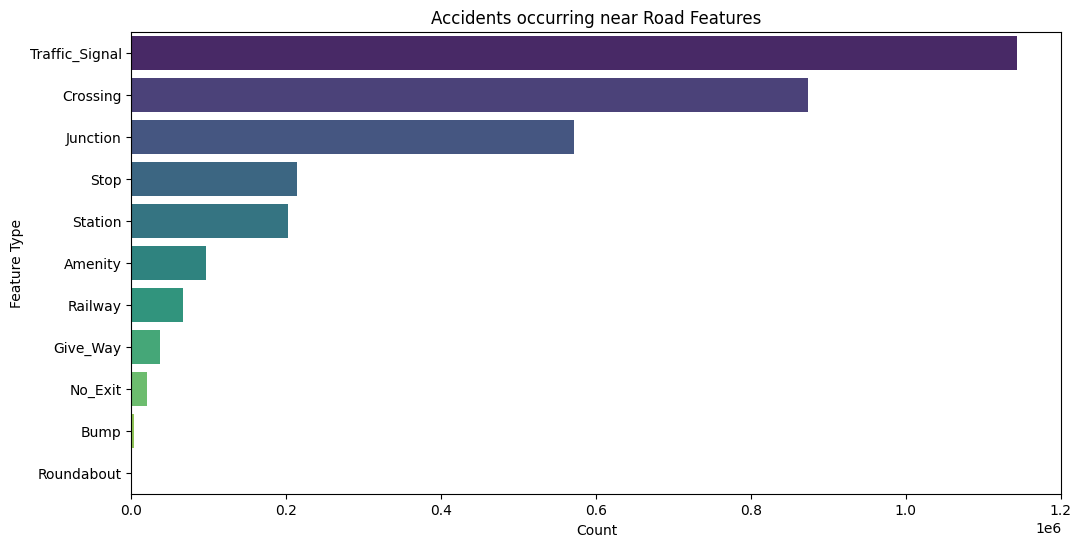

In [11]:
if 'df_accidents' in locals() and df_accidents is not None:
    road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Signal']
    feature_counts = df_accidents[road_features].sum().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x=feature_counts.values, y=feature_counts.index, palette='viridis', hue=feature_counts.index, legend=False)
    plt.title('Accidents occurring near Road Features')
    plt.xlabel('Count')
    plt.ylabel('Feature Type')
    plt.show()
else:
    print("Data not loaded. Skipping visualization.")